In [5]:
import os

from IPython.display import Image, display
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model

load_dotenv()
API_KEY = os.getenv("SILICON_API_KEY")
model = init_chat_model(
    "Qwen/Qwen3-8B",
    model_provider="openai",
    base_url="https://api.siliconflow.cn/v1",
    api_key=API_KEY,
    temperature=0.0
)


def display_graph(app):
    # 使用 Graphviz 渲染（Colab 最稳定的方案）
    try:
        display(Image(app.get_graph(xray=True).draw_png()))
    except Exception as e:
        print(f"Graphviz 渲染失败: {e}")
        print("\n使用 Mermaid 文本方式显示:")
        print(app.get_graph(xray=True).draw_mermaid())

通过大模型决定路由

In [6]:
from typing import TypedDict, Literal

from langchain.messages import HumanMessage


class AgentState(TypedDict):
    messages: list
    next_action: str


def check_message(state: AgentState) -> dict:
    return {"messages": state["messages"]}


def llm_router(state: AgentState) -> Literal["search", "calculate", "respond", "clarify"]:
    """LLM 决定下一步行动"""
    messages = state["messages"]
    last_message = messages[-1].conten

    routing_prompt = f"""
        分析用户的请求，决定下一步行动：

        用户请求：{last_message}

        可选行动：
        - search: 需要搜索信息
        - calculate: 需要计算
        - respond: 可以直接回复
        - clarify: 需要澄清用户意图

        只返回行动名称，不要解释。
        """

    response = model.invoke([HumanMessage(content=routing_prompt)])
    action = response.content.strip().lower()

    # 验证返回值
    valid_actions = ["search", "calculate", "respond", "clarify"]
    return action if action in valid_actions else "clarify"


def search_node(state: AgentState) -> dict:
    """搜索节点"""
    print("🔍 执行搜索...")
    return {"next_action": "search"}


def calculate_node(state: AgentState) -> dict:
    """计算节点"""
    print("🧮 执行计算...")
    return {"next_action": "calculate"}


def respond_node(state: AgentState) -> dict:
    """回复节点"""
    print("💬 生成回复...")
    return {"next_action": "respond"}


def clarify_node(state: AgentState) -> dict:
    """澄清节点"""
    print("❓ 请求澄清...")
    return {"next_action": "clarify"}

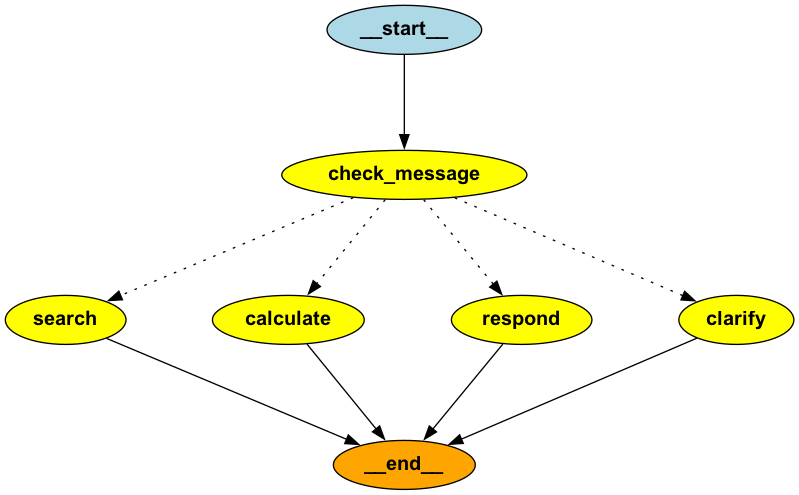

In [7]:
from langgraph.constants import START, END
from langgraph.graph import StateGraph

# 构建图

graph = StateGraph(AgentState)
graph.add_node("check_message", check_message)
graph.add_node("search", search_node)
graph.add_node("calculate", calculate_node)
graph.add_node("respond", respond_node)
graph.add_node("clarify", clarify_node)

graph.add_edge(START, "check_message")
graph.add_conditional_edges(
    "check_message",
    llm_router,
    {
        "search": "search",
        "calculate": "calculate",
        "respond": "respond",
        "clarify": "clarify"
    }
)

for node in ["search", "calculate", "respond", "clarify"]:
    graph.add_edge(node, END)

app = graph.compile()
display_graph(app)